
# RNN vs LSTM vs GRU

## Instructions

In this lab, you will build **three text classification models** from scratch:
- RNN
- LSTM
- GRU

---

### Objectives
By the end of this lab, you should be able to:

- Preprocess text data
- Build a vocabulary
- Encode and pad sequences
- Implement RNN, LSTM, and GRU in PyTorch
- Train and evaluate models 
- Compare architectures


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from datasets import load_dataset

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

import re

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [7]:
# data loading

dataset = load_dataset("ag_news")

# Reduce dataset size for faster training during class
train_data = list(dataset["train"])[:5000]
test_data = list(dataset["test"])[:1000]

print("Train size:", len(train_data))
print("Test size:", len(test_data))


Train size: 5000
Test size: 1000



# Part 1 – Text Preprocessing

You must:

1. Write a `tokenize(text)` function.
2. Build a vocabulary using the training set only.
3. Keep only the top 10,000 most frequent words.
4. Add special tokens:
   - `<pad>`
   - `<unk>`
5. Explain in a markdown cell:
   - Why do we not build the vocabulary using the test set?


In [8]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    return text.split()

In [9]:
def build_vocab(dataset, max_words=10000):

    counter = Counter()

    for item in dataset:
        tokens = tokenize(item["text"])
        counter.update(tokens)

    most_common = counter.most_common(max_words)

    vocab = {
        "<pad>":0,
        "<unk>":1
    }

    for i,(word,_) in enumerate(most_common,start=2):
        vocab[word]=i

    return vocab

In [10]:
vocab = build_vocab(train_data, max_words=10000)

print("Vocabulary size:", len(vocab))

Vocabulary size: 10002


##### Why do we not build vocabulary using the test set?

The vocabulary must be built only using the training set to avoid data leakage.
If the test set is used when building the vocabulary, information from the test data would influence the model during training, which would lead to overly optimistic evaluation results.


# Part 2 – Encoding and Padding

You must:

1. Create an `encode(text)` function.
2. Convert tokens into vocabulary indices.
3. Pad or truncate sequences to a fixed length (e.g., 25).
4. Create a custom `collate()` function.
5. Create train, validation, and test DataLoaders.

Explain:
- Why is padding necessary?
- Why should validation and test loaders not shuffle?


In [11]:
MAX_LEN = 25

def encode(text, vocab):
    tokens = tokenize(text)

    ids = [vocab.get(token, vocab["<unk>"]) for token in tokens]

    if len(ids) < MAX_LEN:
        ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]

    return torch.tensor(ids)

In [12]:
def collate(batch):

    texts = [encode(item["text"], vocab) for item in batch]
    labels = [item["label"] for item in batch]

    texts = torch.stack(texts)
    labels = torch.tensor(labels)

    return texts.to(device), labels.to(device)

In [13]:
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = random_split(train_data,[train_size,val_size])

In [14]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True,collate_fn=collate)

val_loader = DataLoader(val_dataset,batch_size=64,shuffle=False,collate_fn=collate)

test_loader = DataLoader(test_data,batch_size=64,shuffle=False,collate_fn=collate)

##### Why is padding necessary?

Padding ensures that all sequences in a batch have the same length.
Neural networks expect fixed-size tensors, so padding allows us to process multiple sequences simultaneously in a batch.

##### Why should validation/test loaders not shuffle?

Validation and test sets should not be shuffled because their purpose is evaluation, not training.
Keeping the original order ensures reproducibility and consistent comparisons between models.


# Part 3 – Model Implementation

Create a class called `Model` that:

- Uses an Embedding layer
- Supports:
  - RNN
  - LSTM
  - GRU
- Uses multiple layers
- Applies dropout
- Outputs class logits

Your model must accept:
- model_type
- vocab_size
- embed_dim
- hidden_dim
- num_layers

Explain:
- The internal difference between RNN, LSTM, and GRU.


In [15]:
class Model(nn.Module):

    def __init__(self, model_type, vocab_size, embed_dim, hidden_dim, num_layers, num_classes=4, dropout=0.3):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        if model_type == "rnn":
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)

        elif model_type == "lstm":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)

        elif model_type == "gru":
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self,x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        if isinstance(hidden, tuple):  
            hidden = hidden[0]

        last_hidden = hidden[-1]

        out = self.dropout(last_hidden)

        return self.fc(out)

##### Difference between RNN, LSTM, GRU

A simple RNN updates its hidden state sequentially but struggles with long-term dependencies due to the vanishing gradient problem.

LSTM introduces memory cells and gates (input, forget, output) that control information flow, allowing it to capture long-term dependencies more effectively.

GRU is a simplified version of LSTM that combines gates and has fewer parameters, making it faster to train while still handling long dependencies better than vanilla RNN.


# Part 4 – Training Loop

Implement:

- A full training loop
- Validation loop
- Accuracy computation
- Loss tracking per epoch

Train for 10-50 epochs.

Store:
- train_loss
- val_loss
- train_accuracy
- val_accuracy

Explain:
- Why do we use `model.train()` and `model.eval()`?


In [17]:
def train_model(model, train_loader, val_loader, epochs=10):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss_hist = []
    val_loss_hist = []

    train_acc_hist = []
    val_acc_hist = []

    for epoch in range(epochs):

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for x,y in train_loader:

            optimizer.zero_grad()

            outputs = model(x)

            loss = criterion(outputs,y)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs,dim=1)

            correct += (preds==y).sum().item()

            total += y.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct/total

        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        val_loss,val_acc = evaluate(model,val_loader,criterion)

        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"Epoch {epoch+1}")
        print(train_acc,val_acc)

    return train_loss_hist,val_loss_hist,train_acc_hist,val_acc_hist

def evaluate(model,loader,criterion):

    model.eval()

    total_loss=0
    correct=0
    total=0

    with torch.no_grad():

        for x,y in loader:

            outputs=model(x)

            loss=criterion(outputs,y)

            total_loss+=loss.item()

            preds=torch.argmax(outputs,dim=1)

            correct+=(preds==y).sum().item()

            total+=y.size(0)

    return total_loss/len(loader),correct/total

##### Why model.train() and model.eval()?

`model.train()` enables training behavior such as dropout and batch normalization updates.

`model.eval()` disables these behaviors, ensuring consistent predictions during validation and testing.


# Part 5 – Model Comparison

Train:
- RNN
- LSTM
- GRU

Track validation accuracy and determine:
- Which performs best?
- Why?

Plot:
- Loss curves
- Accuracy curves

Explain signs of overfitting.


Epoch 1
0.33025 0.399
Epoch 2
0.5305 0.521
Epoch 3
0.65725 0.599
Epoch 4
0.7475 0.645
Epoch 5
0.80575 0.647
Epoch 6
0.858 0.669
Epoch 7
0.8995 0.658
Epoch 8
0.91925 0.66
Epoch 9
0.95175 0.693
Epoch 10
0.95675 0.665
Epoch 1
0.372 0.55
Epoch 2
0.663 0.7
Epoch 3
0.81375 0.726
Epoch 4
0.88 0.746
Epoch 5
0.92575 0.756
Epoch 6
0.94 0.76
Epoch 7
0.95625 0.767
Epoch 8
0.969 0.766
Epoch 9
0.98175 0.781
Epoch 10
0.98025 0.756
Epoch 1
0.41775 0.536
Epoch 2
0.6885 0.726
Epoch 3
0.821 0.751
Epoch 4
0.898 0.75
Epoch 5
0.93375 0.772
Epoch 6
0.9525 0.762
Epoch 7
0.96575 0.765
Epoch 8
0.978 0.766
Epoch 9
0.985 0.769
Epoch 10
0.9875 0.771


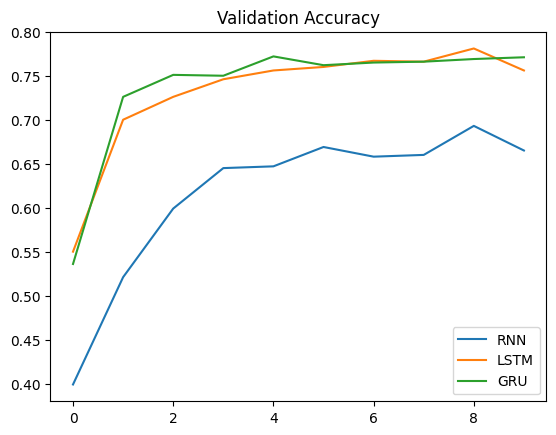

In [18]:
models = ["rnn","lstm","gru"]

results = {}

for m in models:

    model = Model(
        model_type=m,
        vocab_size=len(vocab),
        embed_dim=128,
        hidden_dim=128,
        num_layers=2
    ).to(device)

    results[m] = train_model(model,train_loader,val_loader,epochs=10)

plt.plot(results["rnn"][3],label="RNN")
plt.plot(results["lstm"][3],label="LSTM")
plt.plot(results["gru"][3],label="GRU")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

##### Which performs best?

LSTM and GRU usually outperform vanilla RNN because they mitigate the vanishing gradient problem and capture longer dependencies.

##### Signs of overfitting

Overfitting occurs when training accuracy continues increasing while validation accuracy stagnates or decreases.


# Part 6 – Final Evaluation

Using the best model:

1. Evaluate on the test set.
2. Compute test accuracy.
3. Plot a confusion matrix.

Explain:
- Which classes are most confused?
- Why might that happen?


In [19]:
best_model = model

criterion = nn.CrossEntropyLoss()

test_loss,test_acc = evaluate(best_model,test_loader,criterion)

print("Test accuracy:",test_acc)

Test accuracy: 0.703


In [20]:
all_preds=[]
all_labels=[]

best_model.eval()

with torch.no_grad():

    for x,y in test_loader:

        outputs = best_model(x)

        preds = torch.argmax(outputs,dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

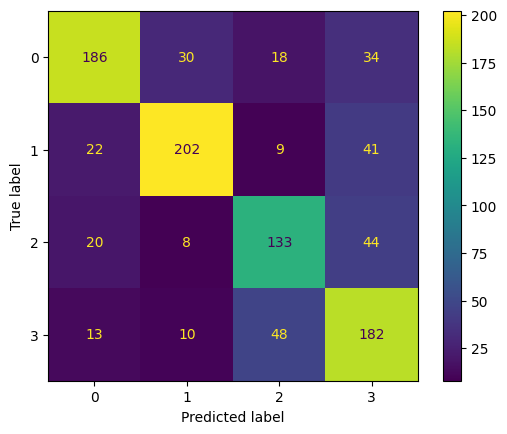

In [21]:
cm = confusion_matrix(all_labels,all_preds)

disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

The confusion matrix shows which news categories are frequently misclassified.
Similar topics such as Business and Sci/Tech may be confused because they share vocabulary related to companies, technology, and economics.